# Exploratory Data Analysis

Notebook Author: Ilan Harari <br>
Data Source: https://pypi.org/project/players-behaviors-dataset-generator/#description 

#### Imports and Data Loading

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
print("All libraries are working!")

All libraries are working!


In [ ]:
#read in data
df = pd.read_csv('../data/raw_data/synthetic_player_data.csv')

### Data Validation & Cleaning



- Data Validation & Cleaning    
    - Assessment of column data types, nulls, duplicates, outliers
    - Column standardization
    - Descriptive Statistics
    - Findings
- Feature Engineering
    -  Extraction
    -  Transformation
    -  Derivation
- Post-Cleaning Validation
    - Validation Report
- Visualizations
    - Time series plots
    - Cohort plots
    - Session plots

#### Assessment of column data types, nulls, duplicates, outliers 

In [3]:
df.columns

Index(['id', 'cohort_id', 'player_id', 'player_type', 'session_id',
       'event_type', 'timestamp', 'stage_id', 'stage_score'],
      dtype='object')

In [4]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6772064 entries, 0 to 6772063
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           object 
 1   cohort_id    object 
 2   player_id    object 
 3   player_type  object 
 4   session_id   object 
 5   event_type   object 
 6   timestamp    object 
 7   stage_id     object 
 8   stage_score  float64
dtypes: float64(1), object(8)
memory usage: 465.0+ MB


,id,cohort_id,player_id,player_type,session_id,event_type,timestamp,stage_id,stage_score
0,0a68f1b2b0954b4cae6b92ed1ef70dbf,2af4a515434c4606836489a579a9f740,ac99c609dc974d4182754b9803a71279,casual,37dfcbf7c2bd487cbc1e06155e419773,BEGIN_SESSION,2025-04-06 12:42:06.694924,NaN,NaN
1,4f42ec16fdcd4668b506d1a2709d16f4,2af4a515434c4606836489a579a9f740,ac99c609dc974d4182754b9803a71279,casual,37dfcbf7c2bd487cbc1e06155e419773,BEGIN_STAGE,2025-04-06 12:45:27.012508,7abbefec-6e62-4241-9bde-ac7a6b9723c9,NaN
2,661ebc6b1ede47f4b23eb12accbeb329,2af4a515434c4606836489a579a9f740,ac99c609dc974d4182754b9803a71279,casual,37dfcbf7c2bd487cbc1e06155e419773,END_STAGE,2025-04-06 12:46:24.705289,7abbefec-6e62-4241-9bde-ac7a6b9723c9,207.0
3,6fab9800706a44648aba9f7126101df0,2af4a515434c4606836489a579a9f740,ac99c609dc974d4182754b9803a71279,casual,37dfcbf7c2bd487cbc1e06155e419773,BEGIN_STAGE,2025-04-06 12:50:04.065869,beb754d3-1ce0-4eca-bcf0-a69d0018af5c,NaN
4,b13d415c4f9a4023ac8feeb941e958fd,2af4a515434c4606836489a579a9f740,ac99c609dc974d4182754b9803a71279,casual,37dfcbf7c2bd487cbc1e06155e419773,END_STAGE,2025-04-06 12:50:48.634408,beb754d3-1ce0-4eca-bcf0-a69d0018af5c,841.0


In [5]:
# 1. Null check
print("\nNull raw:\n",df.isnull().sum().sort_values(ascending=False).head()) #raw null count
print("\nNull rate:\n", df.isnull().sum() / len(df) * 100) #null rate


Null raw:
 stage_score    3544577
stage_id        317090
timestamp            0
event_type           0
session_id           0
dtype: int64

Null rate:
 id              0.000000
cohort_id       0.000000
player_id       0.000000
player_type     0.000000
session_id      0.000000
event_type      0.000000
timestamp       0.000000
stage_id        4.682324
stage_score    52.341162
dtype: float64


In [6]:
# Explore null stage score and stage id
print(df[df['stage_score'].isna()]['event_type'].value_counts())
print(df[df['stage_id'].isna()]['event_type'].value_counts())

BEGIN_STAGE      3227487
END_SESSION       158545
BEGIN_SESSION     158545
Name: event_type, dtype: int64
END_SESSION      158545
BEGIN_SESSION    158545
Name: event_type, dtype: int64


In [7]:
#2. Duplicate check
df.duplicated().sum()

0

In [8]:
# Outlier check - I'm not going to do this yet because I'm not sure if the outliers are valid

# #impute stage_score with upper limit for outliers
# upper_limit = df['stage_score'].quantile(0.75) + 1.5 * (df['stage_score'].quantile(0.75) - df['stage_score'].quantile(0.25))
# print(upper_limit)
# #impute outliers with upper limit
# df['stage_score'] = np.where(df['stage_score'] > upper_limit, upper_limit, df['stage_score'])
# #check if outliers are removed
# df['stage_score'].describe(percentiles=[.25, .5, .75])

# #proceed with lower limit
# lower_limit = df['stage_score'].quantile(0.25) - 1.5 * (df['stage_score'].quantile(0.75) - df['stage_score'].quantile(0.25))
# print(lower_limit)
# #impute outliers with lower limit
# df['stage_score'] = np.where(df['stage_score'] < lower_limit, lower_limit, df['stage_score'])
# #check if outliers are removed
# df['stage_score'].describe(percentiles=[.25, .5, .75])

#### Column standardization

In [9]:
#3. Fix timestamp type
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp'].head()

0   2025-04-06 12:42:06.694924
1   2025-04-06 12:45:27.012508
2   2025-04-06 12:46:24.705289
3   2025-04-06 12:50:04.065869
4   2025-04-06 12:50:48.634408
Name: timestamp, dtype: datetime64[ns]

In [10]:
#add weekday and hour columns
df['weekday'] = df['timestamp'].dt.day_name()
df['hour'] = df['timestamp'].dt.hour

#add week column
df['week'] = df['timestamp'].dt.isocalendar().week

#add day column 
df['day'] = df['timestamp'].dt.day

#check the new columns
df[['timestamp', 'week', 'weekday', 'day', 'hour']].head()

,timestamp,week,weekday,day,hour
0,2025-04-06 12:42:06.694924,14,Sunday,6,12
1,2025-04-06 12:45:27.012508,14,Sunday,6,12
2,2025-04-06 12:46:24.705289,14,Sunday,6,12
3,2025-04-06 12:50:04.065869,14,Sunday,6,12
4,2025-04-06 12:50:48.634408,14,Sunday,6,12


In [11]:
#4. Rename columns
df = df.rename(columns={'id': 'event_id', 'player_type':'player_label', 'cohort_id': 'player_cohort'})

#### Descriptive Statistics

In [12]:
df.describe(include='object')

,event_id,player_cohort,player_id,player_label,session_id,event_type,stage_id,weekday
count,6772064,6772064,6772064,6772064,6772064,6772064,6454974,6772064
unique,6772064,16,37267,3,158545,4,3227487,7
top,7a4059d35f854da6af74a0210983477a,2727be5761d6401ebed5e0e8e2812a4b,c01f082542684ed082c2b2ba6d1c23eb,churner,e8e8c70f670548a18afa30ed3dfa6b8c,END_STAGE,9cf4bb47-17f4-497a-a26b-e178520ec299,Wednesday
freq,1,951754,1346,5141962,88,3227487,2,1459636


In [13]:
#Explore stage score
df['stage_score'].describe(percentiles=[.25, .5, .75, .9, .95, .99, .991, .995])

count    3.227487e+06
mean     6.622053e+02
std      3.938398e+02
min      0.000000e+00
25%      3.630000e+02
50%      6.930000e+02
75%      9.660000e+02
90%      1.120000e+03
95%      1.237000e+03
99%      1.555000e+03
99.1%    1.574000e+03
99.5%    1.682000e+03
max      2.860000e+03
Name: stage_score, dtype: float64

In [14]:
#class balance for player label
df['player_label'].value_counts(normalize=True)

churner     0.759290
hardcore    0.184039
casual      0.056671
Name: player_label, dtype: float64

*Data has been scrubbed for nulls and duplicates, columns renamed for consistency, and datetime typed appropriately.*



#### Findings



- There are 2 columns, `stage_id` and `stage_score` which have null rates of 4% and 52%, respectively. Upon aggregation of these columns with `event_type`, it is apparent that `stage_score` is null only when a player is starting & ending a session, or starting a stage. This is valid and does not warrant imputation. `stage_id` is null only for event types of `BEGIN_SESSION` and `END_SESSION`, which also makes logical sense. No imputation is needed here.

- `stage_score` has many outliers. I'm not ready to impute them yet, would like to know more about those outliers.

- There are 16 unique cohorts of players. Their names are formatted as unique identifiers, which does not clue in as to how they are formed or what they represent. My exploratory analysis will address this to uncover any patterns within and across cohorts.


- The column `player_label` has 3 unique values: `churned`, `casual`, and `hardcore`. This might be useful in a churn prediction model.


### Feature Engineering

- Feature Selection
- Feature Extraction
- Feature Transformation


#### Feature Selection

In [15]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['player_label', 'event_type', 'player_cohort', 'stage_id']
df_encoded = df.copy()

for col in label_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

In [16]:
df_encoded.dtypes

event_id                 object
player_cohort             int64
player_id                object
player_label              int64
session_id               object
event_type                int64
timestamp        datetime64[ns]
stage_id                  int64
stage_score             float64
weekday                  object
hour                      int64
week                     UInt32
day                       int64
dtype: object

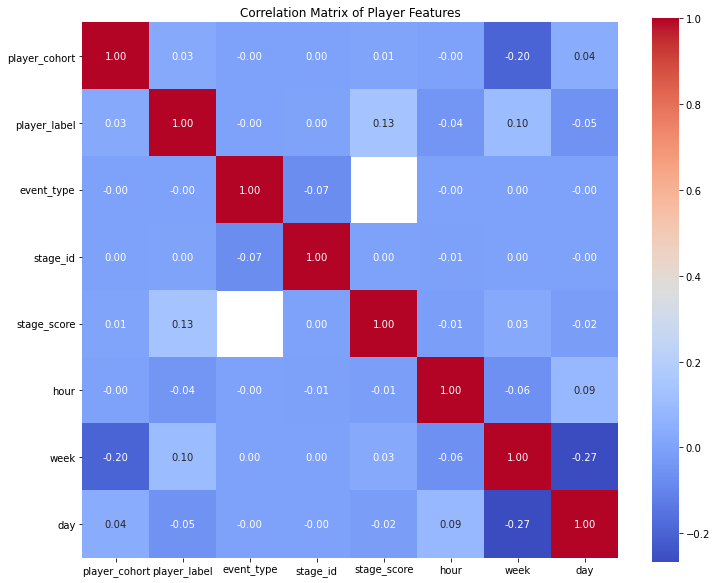

In [17]:
# Select numeric features
numeric_cols = df_encoded.select_dtypes(include=['number'])

# Compute correlation
corr_matrix = numeric_cols.corr()

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix of Player Features")
plt.show()

In [18]:

# Assuming you already have this:
# corr_matrix = numeric_cols.corr()

# Filter for correlations with absolute value ≥ 0.7
threshold = 0.7
strong_corrs = corr_matrix[(corr_matrix.abs() >= threshold) & (corr_matrix.abs() < 1.0)]

# Drop rows and columns where all values are NaN (no strong correlation)
strong_corrs = strong_corrs.dropna(how='all').dropna(axis=1, how='all')

# Display filtered matrix
print("Strong correlations (|r| ≥ 0.7):")
display(strong_corrs)

Strong correlations (|r| ≥ 0.7):


""


`player_label` is correlated with `sessions_per_player` and `events_per_player` with coefficients of 71.6% and 73.2%, respectively.

#### Feature Extraction

#### Feature Transformation

In [19]:
#Calculate events per session
df['events_per_session'] = df.groupby('session_id')['event_type'].transform('count')

In [20]:
#Calculate session length, matching session id
df['session_length'] = df.groupby('session_id')['timestamp'].transform(lambda x: x.max() - x.min())

In [21]:
df['events_per_session'].describe()


count    6.772064e+06
mean     4.755502e+01
std      1.471466e+01
min      2.000000e+00
25%      4.000000e+01
50%      4.200000e+01
75%      5.000000e+01
max      8.800000e+01
Name: events_per_session, dtype: float64

In [22]:
#calculate sessions per player
df['sessions_per_player'] = df.groupby('player_id')['session_id'].transform('nunique')

In [23]:
df['sessions_per_player'].describe()

count    6.772064e+06
mean     6.955244e+00
std      6.673380e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      6.000000e+00
max      3.500000e+01
Name: sessions_per_player, dtype: float64

In [24]:
#calculate events per player
df['events_per_player'] = df.groupby('player_id')['event_id'].transform('nunique')

In [25]:
# DateTime columns
df['weekday'] = df['timestamp'].dt.strftime('%A')
df['hour'] = df['timestamp'].dt.strftime('%H')
df['minute'] = df['timestamp'].dt.strftime('%M')


### Post-Cleaning Validation

- Data Quality Checks
- Compare descriptive statistics after cleaning
- Verify transformations
- Create Validation Report

In [26]:
# Data quality check
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")
# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Number of missing values: {missing_values}")
# Check for data types
data_types = df.dtypes
print(f"Data types:\n{data_types}")
# Check for unique values in categorical columns
categorical_columns = ['event_type', 'player_label', 'player_cohort', 'weekday', 'hour']
for col in categorical_columns:
    unique_values = df[col].nunique()
    print(f"Number of unique values in {col}: {unique_values}")
# Check for outliers in numerical columns
numerical_columns = ['stage_score', 'events_per_session', 'session_length', 'sessions_per_player', 'events_per_player']
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Number of outliers in {col}: {len(outliers)}")
# Check for class imbalance
class_counts = df['player_label'].value_counts()
print(f"Class counts:\n{class_counts}")

Number of duplicates: 0
Number of missing values: 3861667
Data types:
event_id                        object
player_cohort                   object
player_id                       object
player_label                    object
session_id                      object
event_type                      object
timestamp               datetime64[ns]
stage_id                        object
stage_score                    float64
weekday                         object
hour                            object
week                            UInt32
day                              int64
events_per_session               int64
session_length         timedelta64[ns]
sessions_per_player              int64
events_per_player                int64
minute                          object
dtype: object
Number of unique values in event_type: 4
Number of unique values in player_label: 3
Number of unique values in player_cohort: 16
Number of unique values in weekday: 7
Number of unique values in hour: 24
Number of o

In [27]:
# Find null rate, raw and percentage
null_rate = df.isnull().sum() / len(df) * 100
print(f"Null rate:\n{null_rate}")

Null rate:
event_id                0.000000
player_cohort           0.000000
player_id               0.000000
player_label            0.000000
session_id              0.000000
event_type              0.000000
timestamp               0.000000
stage_id                4.682324
stage_score            52.341162
weekday                 0.000000
hour                    0.000000
week                    0.000000
day                     0.000000
events_per_session      0.000000
session_length          0.000000
sessions_per_player     0.000000
events_per_player       0.000000
minute                  0.000000
dtype: float64


#### Data Quality Report

**Data Quality Metrics:**
- Completeness
- Accuracy
- Consistency 

*Completeness:*

2 columns, `stage_id` and `stage_score` have null rates of 4% and 52% null rates, consistent with previous findings.

*Accuracy:*

There are many outliers in the engineered columns. We will look into this in further analysis.

**Cleaning Log:**

In this cleaning process, we identified null values, duplicates, incorrect data types, and 


In [ ]:
#export cleaned data
df.to_csv('../data/processed_data/cleaned_player_data.csv', index=False)